In [76]:
# This cell contains all the necessary imports for the entire project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split



import warnings
warnings.filterwarnings("ignore")

### Load and Explore the Data

In [79]:
# Load the dataset
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

In [80]:
# Create a summary table per order
order_items_summary = order_items.groupby("order_id").agg({
    "price": "sum",              
    "freight_value": "mean",
}).reset_index()

# Merge orders with the summarized order_items table
df = pd.merge(orders, order_items_summary, on="order_id", how="left")

In [81]:
# Merge customer city and state info to the orders table
df = pd.merge(df,customers[["customer_id","customer_city","customer_state"]],on="customer_id" ,how = "left")

In [82]:
# Add customer review score for each order
df = pd.merge(df, reviews[["order_id", "review_score"]], on="order_id", how="left")

In [20]:
print(df.shape)
df.head()

(99992, 13)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,8.72,sao paulo,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,22.76,barreiras,BA,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,19.22,vianopolis,GO,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,27.20,sao goncalo do amarante,RN,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,8.72,santo andre,SP,5.0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99992 non-null  object 
 1   customer_id                    99992 non-null  object 
 2   order_status                   99992 non-null  object 
 3   order_purchase_timestamp       99992 non-null  object 
 4   order_approved_at              99831 non-null  object 
 5   order_delivered_carrier_date   98199 non-null  object 
 6   order_delivered_customer_date  97005 non-null  object 
 7   order_estimated_delivery_date  99992 non-null  object 
 8   price                          99214 non-null  float64
 9   freight_value                  99214 non-null  float64
 10  customer_city                  99992 non-null  object 
 11  customer_state                 99992 non-null  object 
 12  review_score                   99224 non-null 

In [22]:
df.describe()

,price,freight_value,review_score
count,99214.000000,99214.000000,99224.000000
mean,137.600777,20.180990,4.086421
std,210.284622,15.776774,1.347579
min,0.850000,0.000000,1.000000
25%,45.900000,13.370000,4.000000
50%,86.800000,16.350000,5.000000
75%,149.900000,21.180000,5.000000
max,13440.000000,409.680000,5.000000


In [26]:
# missing values
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1793
order_delivered_customer_date    2987
order_estimated_delivery_date       0
price                             778
freight_value                     778
customer_city                       0
customer_state                      0
review_score                      768
dtype: int64

In [28]:
# List of date columns to convert
date_columns =[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
# Converting columns to datetime
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99992 non-null  object        
 1   customer_id                    99992 non-null  object        
 2   order_status                   99992 non-null  object        
 3   order_purchase_timestamp       99992 non-null  datetime64[ns]
 4   order_approved_at              99831 non-null  datetime64[ns]
 5   order_delivered_carrier_date   98199 non-null  datetime64[ns]
 6   order_delivered_customer_date  97005 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99992 non-null  datetime64[ns]
 8   price                          99214 non-null  float64       
 9   freight_value                  99214 non-null  float64       
 10  customer_city                  99992 non-null  object        
 11  customer_state 

In [30]:
df["order_status"].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [36]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categoric_cols = df.select_dtypes(include=['object']).columns

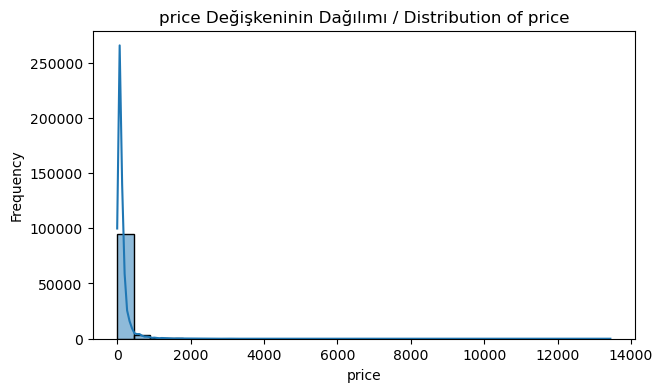

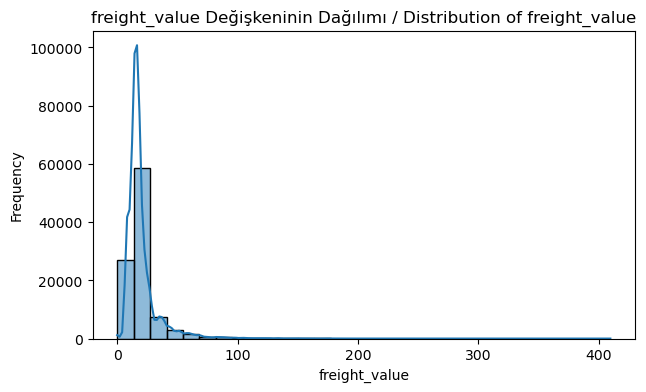

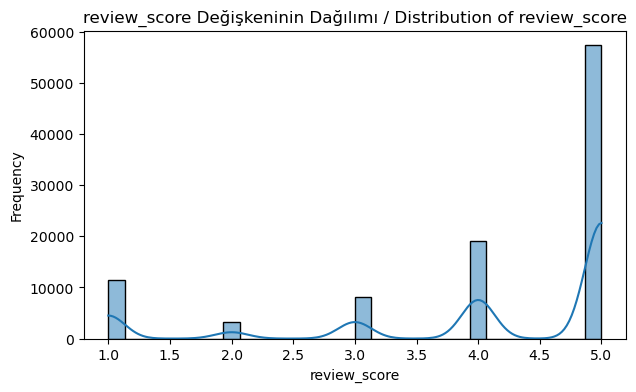

In [63]:
# Histogram for numeric columns
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"{col} Değişkeninin Dağılımı / Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

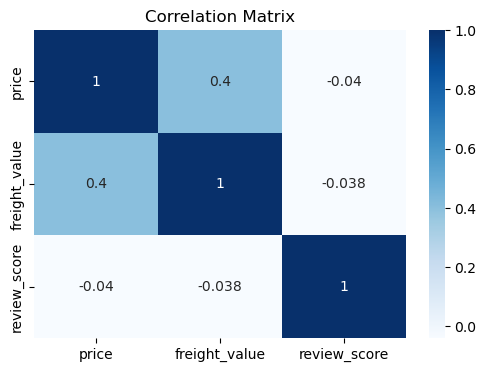

In [67]:
corr =df[numeric_cols].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

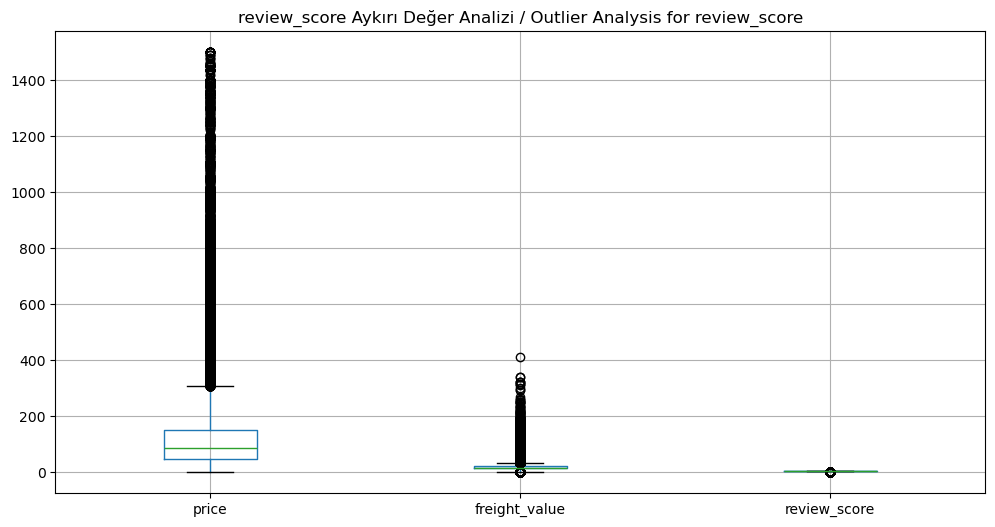

In [78]:
# Outlier Analysis for numeric columns
plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title(f"{col} Aykırı Değer Analizi / Outlier Analysis for {col}")
plt.show()

In [68]:
# Remove rows where price > 1500
df = df[df["price"] <= 1500]
print("Kalan satır sayısı / Remaining rows:", df.shape[0])

Kalan satır sayısı / Remaining rows: 98829


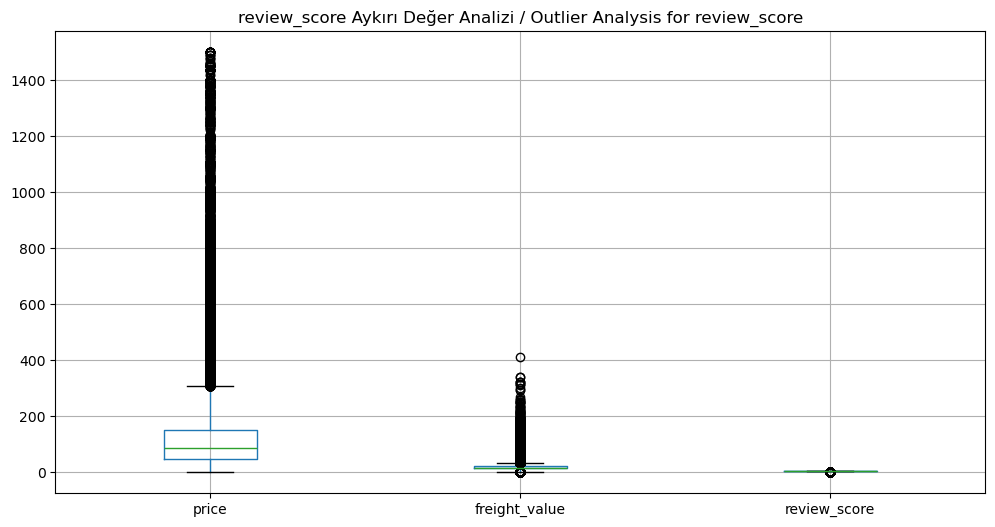

In [69]:
plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title(f"{col} Aykırı Değer Analizi / Outlier Analysis for {col}")
plt.show()

### Train-Test Split

In [77]:
# Create target variable
df["delivered_late"] = (df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]).astype(int)
print(df[["order_estimated_delivery_date", "order_delivered_customer_date", "delivered_late"]].head())
print("Missing values in target:", df["delivered_late"].isna().sum())

  order_estimated_delivery_date order_delivered_customer_date  delivered_late
0                    2017-10-18           2017-10-10 21:25:13               0
1                    2018-08-13           2018-08-07 15:27:45               0
2                    2018-09-04           2018-08-17 18:06:29               0
3                    2017-12-15           2017-12-02 00:28:42               0
4                    2018-02-26           2018-02-16 18:17:02               0
Missing values in target: 0


In [75]:
# Separate features and target
X = df.drop(["delivered_late", "order_id", "customer_id", 
             "order_delivered_customer_date", "order_estimated_delivery_date"], axis=1)
y = df["delivered_late"]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,     
    stratify=y           
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (79063, 9)
X_test : (19766, 9)
